# 1. Podaci: Novi Sad kao graf

Šta se ovde pokazuje: kako grad postaje instanca problema. Zone, ulična mreža,
matrica tražnje i postojeća GSP mreža koja služi kao referenca.

Izvori: OpenStreetMap (ulična mreža i sadržaji), GSP i NSmart portali (linije,
stajališta, red vožnje), JKP Informatika i Popis 2022 (stanovništvo po mesnim
zajednicama), Lazarević (2020) za brojanje putnika po linijama iz 2017. GTFS za
Novi Sad ne postoji, pa se red vožnje skida sa portala i parsira.

Odbačeno je sve što nije gradski prevoz: prigradske linije, mesne zajednice kroz
koje ne prolazi nijedna gradska linija, i stajališta koja ne padaju ni u jednu
mesnu zajednicu. Ostaje 32 zone, i na njima stoje svi brojevi u `results/`.

In [1]:
import sys
from pathlib import Path

KOREN = Path.cwd().parent
sys.path.insert(0, str(KOREN))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

In [2]:
from tndp.novisad.instanca import ucitaj, gsp_mreza
from tndp.novisad.ulice import ucitaj_zone

city, imena = ucitaj()
zone = ucitaj_zone()
print(f"zona u studiji: {city.n}")
print(f"stanovnika ukupno: {sum(int(z['stanovnika']) for z in zone):,}".replace(",", "."))

zona u studiji: 32
stanovnika ukupno: 293.413


## 1.1 Zone

**Zašto mesne zajednice.** Stajališta bi dala graf od nekoliko stotina čvorova, a
politika je trenirana na gradovima od 28 do 36 čvorova. Uz to, mesna zajednica je
jedina jedinica za koju istovremeno postoji granica, broj stanovnika i skup
sadržaja, dakle jedina na kojoj gravitacioni model ima mase s kojima radi.

**Zašto samo gradski saobraćaj.** Prigradske linije su druga tarifna zona i drugi
režim vožnje, a brojanje iz 2017. na koje se kalibriše pokriva gradske linije.
Mešanje ta dva bi značilo kalibraciju na podatak koji ne opisuje ceo sistem.

In [3]:
red = sorted(zone, key=lambda z: -int(z["stanovnika"]))
print(f"{'zona':28s} {'stanovnika':>11s} {'km2':>7s} {'stajalista':>11s}")
for z in red[:10]:
    print(f"{z['mz']:28s} {int(z['stanovnika']):11,d} {float(z['povrsina_km2']):7.2f} "
          f"{z['stajalista_gradska']:>11s}".replace(",", "."))

zona                          stanovnika     km2  stajalista
Детелинара                        21.312    1.28          12
Ветерник                          18.847   14.21          11
Бистрица                          17.779    1.46          19
7. Јули                           15.998    1.12          15
Петроварадин                      15.621   25.78          30
Народни хероји                    15.101    0.92           9
Гаврило Принцип                   13.710    1.43          18
Адице                             13.020    4.07           8
Житни трг                         12.696    0.61          11
Југовићево                        12.136    2.71           4


## 1.2 Ulična mreža

Čvor je zona, ivica postoji između zona koje se graniče, težina je vreme vožnje
iz OSM ulične mreže.

Linija mora da ide ulicom. Da je ivica postojala između svake dve zone, model bi
smeo da napravi liniju koja preskače pola grada u jednom koraku, a takva trasa u
stvarnosti ne postoji. Ivica zato postoji samo između zona koje se graniče, a
težina je najkraće vreme vožnje kroz OSM uličnu mrežu (`tau.csv`).

Cena te odluke je da put kroz zonski graf ume da bude duži od direktnog vremena
kroz uličnu mrežu, jer mora da prođe kroz sve zone između. Koliko duži, meri
`python -m tndp.novisad.instanca` (medijana odnosa i maksimum).

In [4]:
print("prekrsaji:", city.validate() or "nema")
print(f"ivica: {len(city.street_edges)}, prosecan stepen: {2*len(city.street_edges)/city.n:.1f}")
print(f"MST: {city.mst_time:.1f} min")
print(f"donja granica putnickog vremena: {city.street_shortest_mean_demand:.2f} min")

prekrsaji: nema
ivica: 85, prosecan stepen: 5.3
MST: 62.2 min
donja granica putnickog vremena: 9.17 min


## 1.3 Matrica tražnje

Gravitacioni model: masa je stanovništvo, privlačnost su sadržaji iz OSM-a,
opadanje sa daljinom je `beta`.

Merena matrica putovanja za Novi Sad nije objavljena. Objavljeno je brojanje
putnika **po linijama** (Lazarević, 2020), što je projekcija matrice na mrežu, a
ne matrica; iz nje se matrica ne može jednoznačno rekonstruisati.

Gravitacioni model je standardna zamena kad merene matrice nema: produkcija je
stanovništvo, atrakcija su sadržaji iz OSM-a, opadanje sa daljinom je `beta`.
Koristi se ista formula kao u `synth.py`, da se raspodela tražnje na Novom Sadu
ne razlikuje od one na kojoj je politika trenirana.

ukupno putovanja: 97.070
parova sa traznjom > 0: 187 od 496


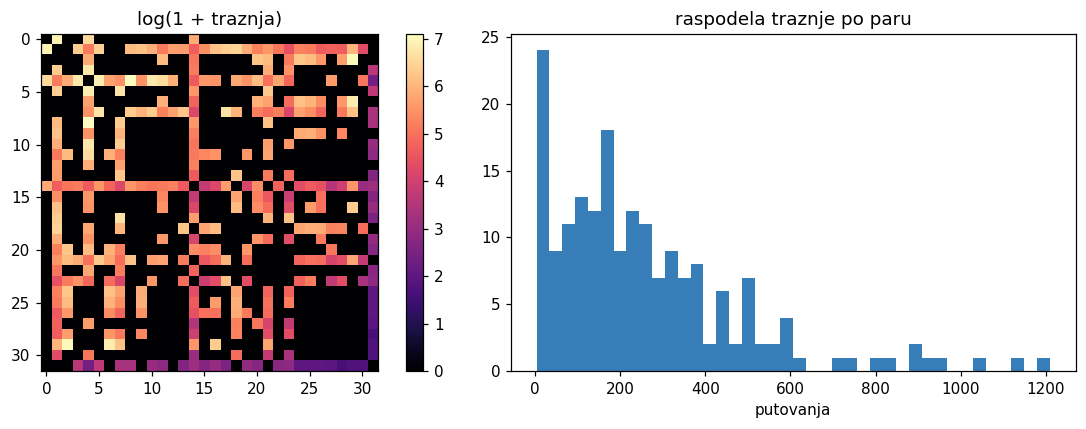

In [5]:
gore = np.triu_indices(city.n, 1)
d = city.demand[gore]
print(f"ukupno putovanja: {city.demand.sum():,.0f}".replace(",", "."))
print(f"parova sa traznjom > 0: {(d > 0).sum()} od {len(d)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(np.log1p(city.demand), cmap="magma")
ax[0].set_title("log(1 + traznja)"); fig.colorbar(im, ax=ax[0])
ax[1].hist(d[d > 0], bins=40, color="#377eb8")
ax[1].set_title("raspodela traznje po paru"); ax[1].set_xlabel("putovanja")
plt.tight_layout()
fig

## 1.4 Kalibracija

Slobodan parametar je pešački prag; `beta` se kalibracijom ne razlikuje.
Detalji i tabela: `results/novisad-kalibracija.md`.

Znači da podatak na koji se kalibriše ne nosi informaciju o `beta`. Pri pragu od
3.5 km ukupno varijaciono rastojanje profila je isto na tri decimale za svaku
vrednost `beta` u ispitanom opsegu; razlikuje ih tek korelacija rangova, i to u
trećoj decimali.

Praktična posledica: prag **jeste** kalibrisan i sme se tako izvestiti, a `beta`
**nije** i ostaje pretpostavka (2.0, koliko koristi i generator). Izvestiti je kao
kalibrisanu značilo bi pripisati podatku zaključak koji iz njega ne sledi.

In [6]:
from IPython.display import Markdown
Markdown((KOREN / "results" / "novisad-kalibracija.md").read_text(encoding="utf-8"))

# Kalibracija gravitacione matrice Novog Sada

Slobodan parametar je `beta`, eksponent opadanja tražnje sa daljinom.
Bira se tako da POSTOJEĆA GSP mreža, opterećena tom matricom, da profil
putovanja po linijama najbliži brojanju iz 2017. Mase zona, privlačnost i
rastojanja su mereni i ne podešavaju se.

Intervali sleđenja su iz reda vožnje (vršni sat 13:00-14:00,
radni dan, smer A), ne procenjeni iz opterećenja. Bez toga poređenje ne bi
bilo pošteno: linija 16 ima 89 vožnji dnevno zato što vozi retko, a ne zato
što tražnje nema.

`prag` je rastojanje ispod kog se putovanje obavi peške i ne ulazi u
prevoz. Bez njega beta nije prepoznatljiva, kalibracija je tera na nulu,
jer gravitacioni model bez praga gomila tražnju na susedne zone.

`TV` je ukupno varijaciono rastojanje profila udela (0 = poklapanje, 1 =
disjunktno). `Spearman` je korelacija rangova linija po opterećenju.
Prikazano je 12 najboljih od 220 kombinacija.

| mera rastojanja | beta | prag (km) | TV | Spearman |
|---|---|---|---|---|
| tau | 3.00 | 3.5 | 0.267 | +0.622 |
| tau | 2.50 | 3.5 | 0.270 | +0.646 |
| tau | 2.00 | 3.5 | 0.272 | +0.646 |
| tau | 2.00 | 3.0 | 0.273 | +0.632 |
| tau | 1.75 | 3.0 | 0.273 | +0.632 |
| tau | 1.75 | 3.5 | 0.273 | +0.646 |
| tau | 1.50 | 3.0 | 0.274 | +0.620 |
| euklidsko | 2.50 | 3.0 | 0.274 | +0.648 |
| euklidsko | 2.00 | 3.0 | 0.274 | +0.648 |
| euklidsko | 1.75 | 3.0 | 0.274 | +0.650 |
| euklidsko | 3.00 | 3.0 | 0.274 | +0.632 |
| tau | 1.25 | 3.0 | 0.274 | +0.609 |

Usvojeno: **mera = euklidsko, beta = 2.0, prag = 3.5 km** (TV 0.278, Spearman +0.648). Svi ostali brojevi u ovom fajlu računati su pri toj vrednosti.

## Šta je kalibracija stvarno odredila

**Prag jeste određen.** TV ima jasan minimum na 3.5 km i raste i ispod
i iznad. 3.5 km je previše za pešačenje i ne treba ga tako čitati, to je
granica ispod koje autobus gubi od pešačenja, bicikla i automobila
zajedno. Novi Sad je ravan i biciklistički, a zone su guste.

**Beta NIJE određena.** Pri pragu 3.5 km je TV jednak na tri decimale za
svaku betu; razlikuje ih tek korelacija rangova, i to u trećoj decimali
(sweep optimum je beta 3.0 sa +0.622,
usvojena beta 2.0 daje +0.648). Kod usvaja
**beta = 2.0**, a ne sweep optimum: razlika je unutar šuma, a
2.0 je vrednost koju koristi `synth.py`, pa se raspodela
tražnje na Novom Sadu ne
razlikuje od one na kojoj je politika trenirana. Isti razlog zbog kog
featuri idu kroz rang transformaciju.

## Profil po linijama pri izabranoj beti

| linija | interval (min) | stvarno | model | razlika |
|---|---|---|---|---|
| 9 | 12.0 | 11.5% | 14.3% | +2.8% |
| 8 | 10.0 | 10.9% | 11.4% | +0.6% |
| 5 | 12.0 | 10.1% | 6.6% | -3.5% |
| 3 | 10.0 | 9.8% | 4.3% | -5.5% |
| 4 | 15.0 | 8.7% | 0.6% | -8.1% |
| 2 | 15.0 | 8.6% | 5.4% | -3.2% |
| 1 | 12.0 | 7.6% | 5.6% | -2.0% |
| 7 | 7.5 | 7.4% | 6.8% | -0.5% |
| 6 | 15.0 | 6.0% | 12.3% | +6.4% |
| 11 | 8.6 | 5.5% | 10.8% | +5.3% |
| 12 | 15.0 | 5.1% | 2.8% | -2.3% |
| 14 | 20.0 | 3.8% | 12.4% | +8.7% |
| 13 | 20.0 | 2.9% | 0.6% | -2.3% |
| 15 | 20.0 | 1.2% | 2.4% | +1.2% |
| 17 | 60.0 | 0.5% | 0.3% | -0.2% |
| 10 | 20.0 | 0.3% | 2.6% | +2.3% |
| 18 | 60.0 | 0.1% | 0.4% | +0.3% |
| 16 | 60.0 | 0.1% | 0.3% | +0.3% |

Nepokrivena tražnja pri toj matrici: 0.000, `C_p` 24.41 min.

## Zašto TV ne pada ispod 0.29

Linije  dobijaju TAČNO nula putnika, iako u stvarnosti nose
0.0% prevoza. Uzrok nije matrica tražnje nego dodela: svaki par zona bira
jedan najbrži put i sva tražnja tog para ide na njega, pa među paralelnim
linijama pobednik uzima sve. Stvarni putnik ulazi u onu liniju koja prva
naiđe, pa se opterećenje deli po frekvencijama (Spiess-Florian, strategija
umesto puta). Taj model ovde nije implementiran i to je gornja granica
tačnosti svakog poređenja po linijama u ovom radu.


## 1.5 Postojeća GSP mreža

Referenca sa kojom se model poredi. 19 osnovnih gradskih linija prevedenih u zone.

Trasa u `linije.csv` je ceo kružni tok linije, dakle oba smera, pa se ista zona u
njoj javlja dvaput. Model gradi proste puteve, pa se iz niza zona uzima najduži
segment bez ponavljanja (`_prost_put`). Posle tog sečenja uzastopne zone ne moraju
više biti susedne, pa se rupe popunjavaju najkraćim putem kroz zonski graf
(`_spoji`); ta dva koraka se ponavljaju dok se niz ne ustali.

Izgubljeno je: smer, tačna trasa unutar zone, i varijante linije (1GL i 1J postaju
linija 1). Koliko je zona pri tom umetnuto ili izbačeno po liniji stoji u dnevniku
koji vraća `gsp_mreza`, i to je gornja granica vernosti svakog poređenja sa GSP-om.

In [7]:
gsp, dnevnik = gsp_mreza(city, imena)
duz = [len(r) for r in gsp.routes]
print(f"linija: {len(gsp.routes)}, duzina min {min(duz)} / medijana {int(np.median(duz))} / max {max(duz)}")
print(f"prekrsaji: {gsp.check(city, len(gsp.routes), min(duz), max(duz)) or 'nema'}")
for d_ in dnevnik[:8]:
    print(f"  {d_['linija']:>3} {d_['zona_sirovo']:3d} -> {d_['zona_trasa']:2d} zona   {d_['naziv'][:42]}")

linija: 19, duzina min 2 / medijana 8 / max 14
prekrsaji: nema
    1  15 ->  8 zona   KLISA - CENTAR - LIMAN 1
    2  11 ->  7 zona   NOVO NASELJE - CENTAR
    3   9 ->  7 zona   DETELINARA - CENTAR - PETROVARADIN
    4  10 -> 11 zona   LIMAN 4 - CENTAR - ŽELEZNIČKA STANICA
    5  17 -> 10 zona   ŽELEZNIČKA STANICA - NAJLON - TEMERINSKI P
    6  20 -> 11 zona   ADICE-CENTAR-PODBARA
    7  16 -> 14 zona   NOVO NASELJE - ŽELEZNIČKA STANICA -FUTOŠKA
    8  22 -> 11 zona   NOVO NASELJE - CENTAR - LIMAN 1


In [ ]:
from tndp.novisad import karta
karta.main()

from IPython.display import Image
Image(str(KOREN / "results" / "novisad-rl.png"))

## Zaključci

Pokazano je da se Novi Sad iz otvorenih podataka sklapa u instancu problema:
32 zone, ulična mreža sa 85 ivica, matrica tražnje i postojeća GSP mreža od 19
linija kao referenca. Pretpostavka je ostala sama matrica, jer je ona model a ne
merenje: brojanje iz 2017 ulazi u kalibraciju, pa nema nezavisnog podatka kojim bi
se proverila.

Najjači nalaz je da kalibracija određuje prag pešačenja, ali ne i `beta`. TV ima
jasan minimum na 3.5 km i raste i ispod i iznad, dok pri tom pragu TV ostaje isti
na tri decimale za svaku vrednost `beta`; razlikuje ih tek korelacija rangova, i to
u trećoj decimali. Nije artefakt jer je mereno nad 220 kombinacija i uz intervale
sleđenja uzete iz stvarnog reda vožnje, a ne procenjene iz opterećenja: bez toga bi
linija koja retko vozi izgledala kao linija bez tražnje. Usvojena je `beta = 2.0`,
ista vrednost koju koristi `synth.py`, da se raspodela tražnje na Novom Sadu ne
razlikuje od one na kojoj je politika trenirana.

Sledeći korak je provera matrice podatkom koji u kalibraciju nije ušao, jer se
prag od 3.5 km oslanja na jedno brojanje iz 2017. Dok toga nema, svaki zaključak o
Novom Sadu treba čitati kao zaključak o ovom modelu grada.